**This function is for check the GPU name and version we are using to run our code.**

In [ ]:
!nvidia-smi

Tue Jun 30 05:01:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**We are installing here library named ULTRALYTICS to use YOLOv8.**

In [ ]:
pip install ultralytics

**Here, we are simply checking that the library I have installed is working fine or not by predcting an image with YOLOv8 model**

In [ ]:
!yolo predict model=yolov8n.pt source='https://ultralytics.com/images/bus.jpg'

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 52.8ms
Speed: 3.9ms preprocess, 52.8ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-2
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
!yolo predict model=yolov8n.pt source='images/cat.jpeg'

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 1080, in entrypoint
    getattr(model, mode)(**overrides)  # default args from model
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 541, in predict
    return self.predictor.predict_cli(source=source) if is_cli else self.predictor(source=source, stream=stream)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/predictor.py", line 247, in predict_cli
    for _ in gen:  # sourcery skip: remove-empty-nested-block, noqa
             ^^^
  File "/usr/local/lib/python3.12

**Now, from here we are using our own custom dataset to train the machine .**

In [ ]:
!pip install ultralytics
from IPython import display
display.clear_output()
import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.20 🚀 Python-3.10.12 torch-2.2.1+cu121 CPU (Intel Xeon 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 28.9/107.7 GB disk)


In [ ]:
from ultralytics import YOLO
from IPython.display import display, Image

**Here, I have uploaded our dataset folder to google drive and simply mounting the colab to drive.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Here, we change our directory to the folder I kept in my drive.**

In [ ]:
%cd /content/drive/MyDrive/data_sets

/content/drive/MyDrive/data_sets


In [ ]:
!ls

bus.jpg		  datasets	     runs				  yolov8n.pt
Custom_data.yaml  default_copy.yaml  TrafficSignLocalizationandDetection  yolov8s.pt


**This is the simple task to detect the images from our dataset
Here, we are using data=data.yaml because we kept the address of the images and number of classes along with classes name in our data.yaml file.
We are using epochs value 100 here because we want to learn the machine about our data 100 times.**

In [ ]:
!yolo copy-cfg

/usr/local/lib/python3.10/dist-packages/ultralytics/cfg/default.yaml copied to /content/drive/MyDrive/data_sets/default_copy.yaml
Example YOLO command with this new custom cfg:
    yolo cfg='/content/drive/MyDrive/data_sets/default_copy.yaml' imgsz=320 batch=8


In [ ]:
%cd /content/drive/MyDrive/data_sets

!yolo task=detect mode=train model=yolov8s.pt data=Custom_data.yaml epochs=100 imgsz=228 plots=True  fliplr=0 flipud=0    #degrees=-5 - 5, shear= -5 - 5 augment=false

/content/drive/MyDrive/data_sets
Ultralytics YOLOv8.2.20 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=Custom_data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=228, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train12, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=T

ModuleNotFoundError: No module named 'ultralytics'

In [5]:
# ============================================================
# STEP 1 : Check GPU
# ============================================================

!nvidia-smi

Mon Aug  3 18:36:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
# ============================================================
# STEP 2 : Install Ultralytics
# ============================================================

!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.8 MB/s eta 0:00:00


In [10]:
# ============================================================
# STEP 3 : Import Libraries
# ============================================================

from ultralytics import YOLO
import ultralytics

from google.colab import drive
from IPython.display import Image, display

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
# ============================================================
# STEP 4 : Verify Installation
# ============================================================

ultralytics.checks()

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)


In [12]:
# ============================================================
# STEP 5 : Mount Google Drive
# ============================================================

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# STEP 6 : Move to Dataset Folder
# ============================================================

%cd /content/drive/MyDrive/Diploma Major Project(DCSE691)/data_sets/TrafficSignLocalizationandDetection

/content/drive/MyDrive/Diploma Major Project(DCSE691)/data_sets/TrafficSignLocalizationandDetection


In [ ]:
# ============================================================
# STEP 7 : Verify Dataset
# ============================================================

!ls

Custom_data.yaml  test	train  valid


In [ ]:
!cat Custom_data.yaml
# ============================================================
# STEP 8 : Test Pretrained YOLO
# ============================================================

# !yolo predict \
# model=yolov8s.pt \
# source="https://ultralytics.com/images/bus.jpg"

path: .

train: train/images
val: valid/images
test: test/images

names:
  - Cycle Zone
  - Danger Ahead
  - Deer Zone
  - End of Right Road -Go straight-
  - Give Way
  - Go Left or Straight
  - Go Right or Straight
  - Go Straight
  - Huddle Road
  - Left Curve Ahead
  - Left Sharp Curve
  - No Entry
  - No Over Taking Trucks
  - No Over Taking
  - No Stopping
  - No Waiting
  - Pedestrian
  - Right Curve Ahead
  - Right Sharp Curve
  - Road Work
  - RoundAbout
  - Slippery Road
  - Snow Warning Sign
  - Speed Limit 100
  - Speed Limit 120
  - Speed Limit 20
  - Speed Limit 30
  - Speed Limit 50
  - Speed Limit 60
  - Speed Limit 70
  - Speed Limit 80
  - Stop
  - Traffic Signals Ahead
  - Truck Sign
  - Turn Left
  - Turn Right


In [ ]:
# ============================================================
# STEP 9 : Load Pretrained Model
# ============================================================

model = YOLO("yolov8s.pt")

In [ ]:
!cat Custom_data.yaml

path: .

train: train/images
val: valid/images
test: test/images

names:
  - Cycle Zone
  - Danger Ahead
  - Deer Zone
  - End of Right Road -Go straight-
  - Give Way
  - Go Left or Straight
  - Go Right or Straight
  - Go Straight
  - Huddle Road
  - Left Curve Ahead
  - Left Sharp Curve
  - No Entry
  - No Over Taking Trucks
  - No Over Taking
  - No Stopping
  - No Waiting
  - Pedestrian
  - Right Curve Ahead
  - Right Sharp Curve
  - Road Work
  - RoundAbout
  - Slippery Road
  - Snow Warning Sign
  - Speed Limit 100
  - Speed Limit 120
  - Speed Limit 20
  - Speed Limit 30
  - Speed Limit 50
  - Speed Limit 60
  - Speed Limit 70
  - Speed Limit 80
  - Stop
  - Traffic Signals Ahead
  - Truck Sign
  - Turn Left
  - Turn Right


In [ ]:
!ls
!ls train

Custom_data.yaml  test	train  valid  yolov8s.pt
images	labels


In [ ]:
# ============================================================
# STEP 10 : Train Model
# ============================================================

results = model.train(

    data="Custom_data.yaml",

    epochs=100,

    imgsz=640,

    batch=16,

    patience=20,

    seed=42,

    workers=2,

    device=0,

    project="/content/drive/MyDrive/Diploma Major Project(DCSE691)",

    name="TrafficSign_TrainedModel",

    exist_ok=True,

    plots=True,

    fliplr=0.0,

    flipud=0.0,

    degrees=5,

    translate=0.10,

    scale=0.30,

    shear=2.0,

    perspective=0.0005,

    hsv_h=0.015,

    hsv_s=0.70,

    hsv_v=0.40
)

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Custom_data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=TrafficSign_TrainedModel, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

In [ ]:
# ============================================================
# STEP 11 : Evaluate Model
# ============================================================

metrics = model.val()

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,139,516 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.4 ms, read: 14.8±5.3 MB/s, size: 22.9 KB)
val: Scanning /content/drive/My Drive/Diploma Major Project(DCSE691)/data_sets/TrafficSignLocalizationandDetection/valid/labels... 173 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 173/173 1.2it/s 2:19
val: New cache created: /content/drive/My Drive/Diploma Major Project(DCSE691)/data_sets/TrafficSignLocalizationandDetection/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.6it/s 4.3s
                   all        173        212      0.707      0.537      0.665       0.49
          Danger Ahead          6          7      0.413      0.714      0.716      0.514
              Give Way          6          6      0.936      0.833      0.835      0.483
  Go Righ

In [ ]:
# ============================================================
# STEP 12 : Predict on Test Images
# ============================================================

model.predict(

    source="test/images",

    save=True,

    conf=0.25
)


image 1/173 /content/drive/MyDrive/Diploma Major Project(DCSE691)/data_sets/TrafficSignLocalizationandDetection/test/images/000000_jpg.rf.9c2d93c681b7d38d50bf4f096a6baf03.jpg: 640x640 1 Speed Limit 30, 16.3ms
image 2/173 /content/drive/MyDrive/Diploma Major Project(DCSE691)/data_sets/TrafficSignLocalizationandDetection/test/images/000009_jpg.rf.cc33de74b89146e17af41bc7322b917c.jpg: 640x640 1 Speed Limit 30, 39.9ms
image 3/173 /content/drive/MyDrive/Diploma Major Project(DCSE691)/data_sets/TrafficSignLocalizationandDetection/test/images/000012_jpg.rf.13a60308c1d3ca9ae9c95a99a12eac4c.jpg: 640x640 1 Speed Limit 30, 28.2ms
image 4/173 /content/drive/MyDrive/Diploma Major Project(DCSE691)/data_sets/TrafficSignLocalizationandDetection/test/images/000015_jpg.rf.b6cf94e07797cace72810114cfe7029c.jpg: 640x640 1 Speed Limit 30, 16.9ms
image 5/173 /content/drive/MyDrive/Diploma Major Project(DCSE691)/data_sets/TrafficSignLocalizationandDetection/test/images/00003-1-_jpg.rf.c3de23cddbbe89173b17b90

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Cycle Zone', 1: 'Danger Ahead', 2: 'Deer Zone', 3: 'End of Right Road -Go straight-', 4: 'Give Way', 5: 'Go Left or Straight', 6: 'Go Right or Straight', 7: 'Go Straight', 8: 'Huddle Road', 9: 'Left Curve Ahead', 10: 'Left Sharp Curve', 11: 'No Entry', 12: 'No Over Taking Trucks', 13: 'No Over Taking', 14: 'No Stopping', 15: 'No Waiting', 16: 'Pedestrian', 17: 'Right Curve Ahead', 18: 'Right Sharp Curve', 19: 'Road Work', 20: 'RoundAbout', 21: 'Slippery Road', 22: 'Snow Warning Sign', 23: 'Speed Limit 100', 24: 'Speed Limit 120', 25: 'Speed Limit 20', 26: 'Speed Limit 30', 27: 'Speed Limit 50', 28: 'Speed Limit 60', 29: 'Speed Limit 70', 30: 'Speed Limit 80', 31: 'Stop', 32: 'Traffic Signals Ahead', 33: 'Truck Sign', 34: 'Turn Left', 35: 'Turn Right'}
 obb: None
 orig_img: array([[[156,  96,  67],
         [155,  95,  66],
         [15

In [ ]:
# ============================================================
# STEP 13 : Save the predicted images in below folder path
# ============================================================

results = model.predict(
    source="test/images/000009_jpg.rf.cc33de74b89146e17af41bc7322b917c.jpg",
    save=True,
    project="/content/drive/MyDrive/Diploma Major Project(DCSE691)",
    name="Prediction_Results",
    exist_ok=True
)


image 1/1 /content/drive/MyDrive/Diploma Major Project(DCSE691)/data_sets/TrafficSignLocalizationandDetection/test/images/000009_jpg.rf.cc33de74b89146e17af41bc7322b917c.jpg: 640x640 1 Speed Limit 30, 16.3ms
Speed: 3.1ms preprocess, 16.3ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/Diploma Major Project(DCSE691)/Prediction_Results


In [ ]:
# ============================================================
# : Call the model which we trained for predictions which is stored in best.pt file
# ============================================================

from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Diploma Major Project(DCSE691)/TrafficSign_TrainedModel/weights/best.pt")

In [ ]:
# ============================================================
#  Manually import image to collab and predict the image.
# ============================================================

from google.colab import files
uploaded = files.upload()

results = model.predict(
    source="123456.png",
    conf=0.25,
    save=True
)

Saving 123456.png to 123456.png


Saved in: /content/runs/detect/predict


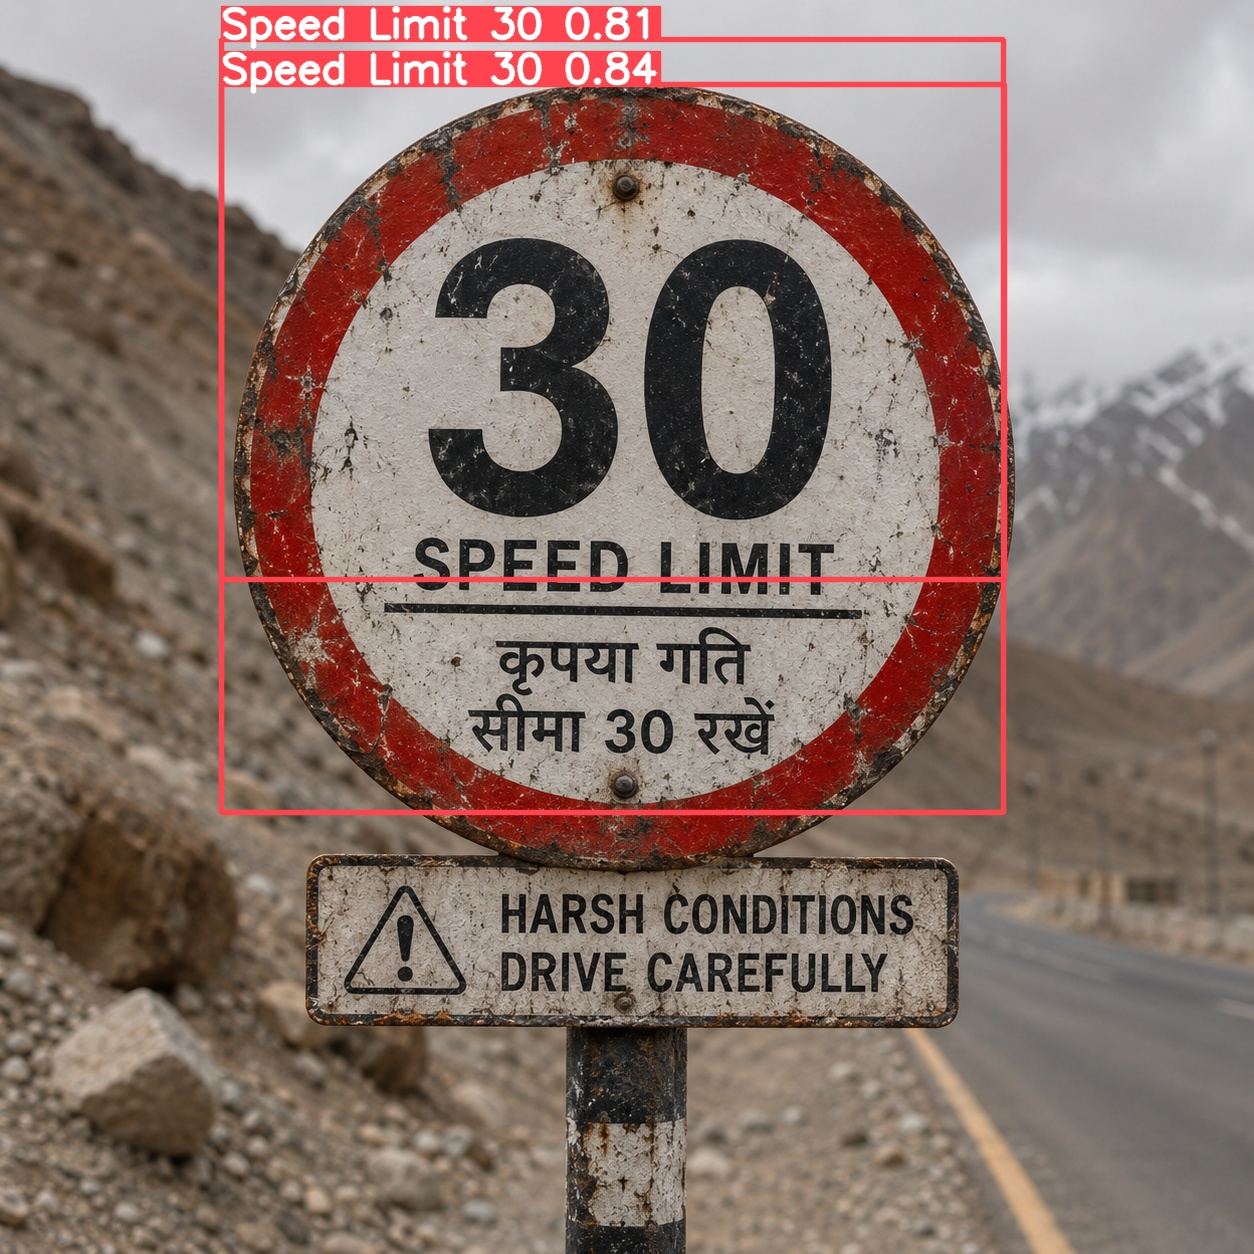

In [ ]:
# ============================================================
#  To see the predicted image class and box boundry here temporary from collab content/runs/detect/predict/...png
# ============================================================

from IPython.display import Image

save_dir = results[0].save_dir
print("Saved in:", save_dir)

Image(filename=f"{save_dir}/123456.jpg")

In [ ]:
# ============================================================
# STEP 13 : Export Model
# ============================================================

model.export(format="onnx")
display(Image(filename="TrafficSign_Project/YOLOv8_Training/results.png"))

NameError: name 'model' is not defined